# Final Holdout Error Analysis

This notebook analyzes where the v1 operational forecasting model makes errors on the locked May 25–31 holdout.

The model uses archived 24-hour-ahead weather forecasts, lagged demand features, rolling demand features, and station identity.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance

PROJECT_ROOT = Path.cwd().parent
FEATURES_FILE = PROJECT_ROOT / "data" / "processed" / "model_features.parquet"

features = pd.read_parquet(FEATURES_FILE)

features.head()

,timestamp,station_id,station_name,pickups,temperature_c,apparent_temperature_c,relative_humidity_pct,precipitation_mm,wind_speed_kmh,weather_code,...,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,lag_24,lag_48,lag_168,lag_336,rolling_mean_168,rolling_std_168
0,2026-01-15 00:00:00,5340.01,N 7 St & Driggs Ave,2,6.4,2.9,69,0.0,10.2,3,...,0.000000,1.000000,0.433884,-0.900969,2.0,3.0,4.0,8.0,9.059524,8.552551
1,2026-01-15 01:00:00,5340.01,N 7 St & Driggs Ave,2,6.2,2.8,67,0.0,9.4,3,...,0.258819,0.965926,0.433884,-0.900969,0.0,0.0,1.0,7.0,9.047619,8.563821
2,2026-01-15 02:00:00,5340.01,N 7 St & Driggs Ave,1,6.5,2.9,81,0.0,14.4,3,...,0.500000,0.866025,0.433884,-0.900969,0.0,0.0,0.0,14.0,9.041667,8.569794
3,2026-01-15 03:00:00,5340.01,N 7 St & Driggs Ave,0,6.3,2.6,80,0.0,14.2,3,...,0.707107,0.707107,0.433884,-0.900969,0.0,0.0,0.0,2.0,9.035714,8.575758
4,2026-01-15 04:00:00,5340.01,N 7 St & Driggs Ave,0,5.9,2.5,81,0.0,12.7,3,...,0.866025,0.500000,0.433884,-0.900969,0.0,0.0,0.0,0.0,9.035714,8.575758


In [3]:
FINAL_TEST_START = pd.Timestamp("2026-05-25")
FINAL_TEST_END = pd.Timestamp("2026-06-01")

TARGET_COLUMN = "pickups"

CATEGORICAL_FEATURES = [
    "station_id",
]

NUMERIC_FEATURES = [
    "temperature_c",
    "apparent_temperature_c",
    "relative_humidity_pct",
    "precipitation_mm",
    "wind_speed_kmh",
    "weather_code",
    "is_precipitating",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "lag_24",
    "lag_48",
    "lag_168",
    "lag_336",
    "rolling_mean_168",
    "rolling_std_168",
]

FEATURE_COLUMNS = CATEGORICAL_FEATURES + NUMERIC_FEATURES

train = features[features["timestamp"] < FINAL_TEST_START].copy()
test = features[
    (features["timestamp"] >= FINAL_TEST_START)
    & (features["timestamp"] < FINAL_TEST_END)
].copy()

X_train = train[FEATURE_COLUMNS]
y_train = train[TARGET_COLUMN]

X_test = test[FEATURE_COLUMNS]
y_test = test[TARGET_COLUMN]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "station",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_FEATURES,
        ),
        (
            "numeric",
            "passthrough",
            NUMERIC_FEATURES,
        ),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            HistGradientBoostingRegressor(
                loss="poisson",
                learning_rate=0.08,
                max_iter=200,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                early_stopping=False,
                random_state=42,
            ),
        ),
    ]
)

model.fit(X_train, y_train)

predictions = test[
    [
        "timestamp",
        "station_id",
        "station_name",
        "pickups",
        "temperature_c",
        "precipitation_mm",
        "is_precipitating",
        "hour",
        "day_of_week",
        "is_weekend",
    ]
].copy()

predictions["prediction"] = model.predict(X_test)
predictions["prediction"] = predictions["prediction"].clip(lower=0)
predictions["error"] = predictions["prediction"] - predictions["pickups"]
predictions["absolute_error"] = predictions["error"].abs()
predictions["squared_error"] = predictions["error"] ** 2

mae = mean_absolute_error(predictions["pickups"], predictions["prediction"])
rmse = np.sqrt(mean_squared_error(predictions["pickups"], predictions["prediction"]))

mae, rmse

(4.853364535101308, np.float64(7.398426725400529))

## Error by Day

First, we aggregate errors by calendar day to see whether the model struggled on specific days of the final holdout.

In [5]:
daily_model_errors = (
    predictions.assign(date=predictions["timestamp"].dt.date)
    .groupby("date")
    .agg(
        total_pickups=("pickups", "sum"),
        total_predicted=("prediction", "sum"),
        mae=("absolute_error", "mean"),
        rmse=("squared_error", lambda x: np.sqrt(x.mean())),
    )
    .reset_index()
)

daily_weather = (
    predictions[
        [
            "timestamp",
            "temperature_c",
            "precipitation_mm",
            "is_precipitating",
        ]
    ]
    .drop_duplicates("timestamp")
    .assign(date=lambda df: df["timestamp"].dt.date)
    .groupby("date")
    .agg(
        mean_temperature_c=("temperature_c", "mean"),
        total_precipitation_mm=("precipitation_mm", "sum"),
        precipitating_hours=("is_precipitating", "sum"),
    )
    .reset_index()
)

daily_errors = daily_model_errors.merge(daily_weather, on="date")

daily_errors

,date,total_pickups,total_predicted,mae,rmse,mean_temperature_c,total_precipitation_mm,precipitating_hours
0,2026-05-25,6631,6891.092046,6.597429,9.763456,16.583333,4.1,7
1,2026-05-26,11526,10568.392191,4.787338,7.670232,19.566667,0.0,0
2,2026-05-27,12329,11573.906703,4.730520,7.123256,23.758333,0.0,0
3,2026-05-28,11956,11547.491799,4.117807,6.382293,19.662500,0.4,1
4,2026-05-29,11635,12265.097579,4.681840,6.846271,19.175000,0.0,0
5,2026-05-30,8599,9265.462667,4.703577,6.694695,15.333333,0.0,0
6,2026-05-31,9099,8998.930742,4.355040,6.770132,16.841667,0.0,0


## Error by Hour

Next, we aggregate errors by hour of day to see whether the model struggles more during commute peaks, midday demand, or overnight periods.

In [6]:
hourly_errors = (
    predictions
    .groupby("hour")
    .agg(
        actual_pickups=("pickups", "sum"),
        predicted_pickups=("prediction", "sum"),
        mae=("absolute_error", "mean"),
        rmse=("squared_error", lambda x: np.sqrt(x.mean())),
    )
    .reset_index()
)

hourly_errors

,hour,actual_pickups,predicted_pickups,mae,rmse
0,0,838,836.973035,2.562571,3.588403
1,1,500,497.093630,1.897141,2.824349
2,2,251,233.449906,1.068188,1.597502
3,3,165,173.064926,0.913643,1.353543
4,4,133,145.272955,0.769063,1.035302
5,5,521,528.767414,1.972424,3.328349
6,6,1220,1302.812654,3.355040,5.291500
7,7,2169,2281.315955,5.104024,7.361652
8,8,3676,3686.481141,7.174731,9.710294
9,9,3331,3408.027511,5.350674,7.050912


### Hourly Error Interpretation

The largest errors occur during high-volume commute and evening periods. At some peak hours, total predicted demand is close to actual demand, but station-level errors remain high. This suggests the model captures overall temporal demand patterns better than exact station-level redistribution during peak periods.

In [7]:
hourly_errors_with_bias = hourly_errors.copy()

hourly_errors_with_bias["total_error"] = (
    hourly_errors_with_bias["predicted_pickups"]
    - hourly_errors_with_bias["actual_pickups"]
)

hourly_errors_with_bias["relative_error_pct"] = (
    hourly_errors_with_bias["total_error"]
    / hourly_errors_with_bias["actual_pickups"]
    * 100
)

hourly_errors_with_bias[
    [
        "hour",
        "actual_pickups",
        "predicted_pickups",
        "total_error",
        "relative_error_pct",
        "mae",
        "rmse",
    ]
].round(2)

,hour,actual_pickups,predicted_pickups,total_error,relative_error_pct,mae,rmse
0,0,838,836.97,-1.03,-0.12,2.56,3.59
1,1,500,497.09,-2.91,-0.58,1.90,2.82
2,2,251,233.45,-17.55,-6.99,1.07,1.60
3,3,165,173.06,8.06,4.89,0.91,1.35
4,4,133,145.27,12.27,9.23,0.77,1.04
5,5,521,528.77,7.77,1.49,1.97,3.33
6,6,1220,1302.81,82.81,6.79,3.36,5.29
7,7,2169,2281.32,112.32,5.18,5.10,7.36
8,8,3676,3686.48,10.48,0.29,7.17,9.71
9,9,3331,3408.03,77.03,2.31,5.35,7.05


## Error by Station

Next, we aggregate errors by station to identify locations where the model performs best and worst during the final holdout.

In [8]:
station_errors = (
    predictions
    .groupby(["station_id", "station_name"])
    .agg(
        actual_pickups=("pickups", "sum"),
        predicted_pickups=("prediction", "sum"),
        mae=("absolute_error", "mean"),
        rmse=("squared_error", lambda x: np.sqrt(x.mean())),
    )
    .reset_index()
)

station_errors["total_error"] = (
    station_errors["predicted_pickups"]
    - station_errors["actual_pickups"]
)

station_errors["relative_error_pct"] = (
    station_errors["total_error"]
    / station_errors["actual_pickups"]
    * 100
)

station_errors.sort_values("mae", ascending=False).round(2)

,station_id,station_name,actual_pickups,predicted_pickups,mae,rmse,total_error,relative_error_pct
23,6912.01,7 Ave & Central Park South,3411,3207.59,5.95,9.91,-203.41,-5.96
13,6331.01,W 31 St & 7 Ave,3111,3010.50,5.78,8.31,-100.50,-3.23
15,6432.09,Park Ave & E 42 St,2839,2830.50,5.76,9.17,-8.50,-0.30
18,6492.08,9 Ave & W 33 St,3137,3055.02,5.69,9.72,-81.98,-2.61
16,6450.05,8 Ave & W 31 St,2529,2402.48,5.47,8.07,-126.52,-5.00
24,6948.10,Broadway & W 58 St,3282,3081.59,5.46,7.74,-200.41,-6.11
14,6364.07,6 Ave & W 33 St,2907,2794.82,5.34,7.82,-112.18,-3.86
17,6459.07,W 30 St & 10 Ave,2825,3036.69,5.33,7.48,211.69,7.49
9,6140.05,W 21 St & 6 Ave,4092,3825.17,5.30,7.92,-266.83,-6.52
12,6233.04,Pier 61 at Chelsea Piers,3936,3895.79,5.16,8.27,-40.21,-1.02


### Station Error Interpretation

Station-level errors are highest around Midtown, Penn Station, Chelsea, and Central Park South. These are high-volume areas with commuter, tourist, and event-driven demand, so they are naturally harder to predict exactly.

One selected station, Lafayette St & E 8 St, had zero actual pickups during the May holdout. This likely reflects a station availability or metadata issue rather than normal demand forecasting error. Future versions should account for station availability before generating predictions.

In [9]:
active_station_errors = station_errors[station_errors["actual_pickups"] > 0].copy()

active_station_errors.sort_values("mae", ascending=False).round(2)

,station_id,station_name,actual_pickups,predicted_pickups,mae,rmse,total_error,relative_error_pct
23,6912.01,7 Ave & Central Park South,3411,3207.59,5.95,9.91,-203.41,-5.96
13,6331.01,W 31 St & 7 Ave,3111,3010.50,5.78,8.31,-100.50,-3.23
15,6432.09,Park Ave & E 42 St,2839,2830.50,5.76,9.17,-8.50,-0.30
18,6492.08,9 Ave & W 33 St,3137,3055.02,5.69,9.72,-81.98,-2.61
16,6450.05,8 Ave & W 31 St,2529,2402.48,5.47,8.07,-126.52,-5.00
24,6948.10,Broadway & W 58 St,3282,3081.59,5.46,7.74,-200.41,-6.11
14,6364.07,6 Ave & W 33 St,2907,2794.82,5.34,7.82,-112.18,-3.86
17,6459.07,W 30 St & 10 Ave,2825,3036.69,5.33,7.48,211.69,7.49
9,6140.05,W 21 St & 6 Ave,4092,3825.17,5.30,7.92,-266.83,-6.52
12,6233.04,Pier 61 at Chelsea Piers,3936,3895.79,5.16,8.27,-40.21,-1.02


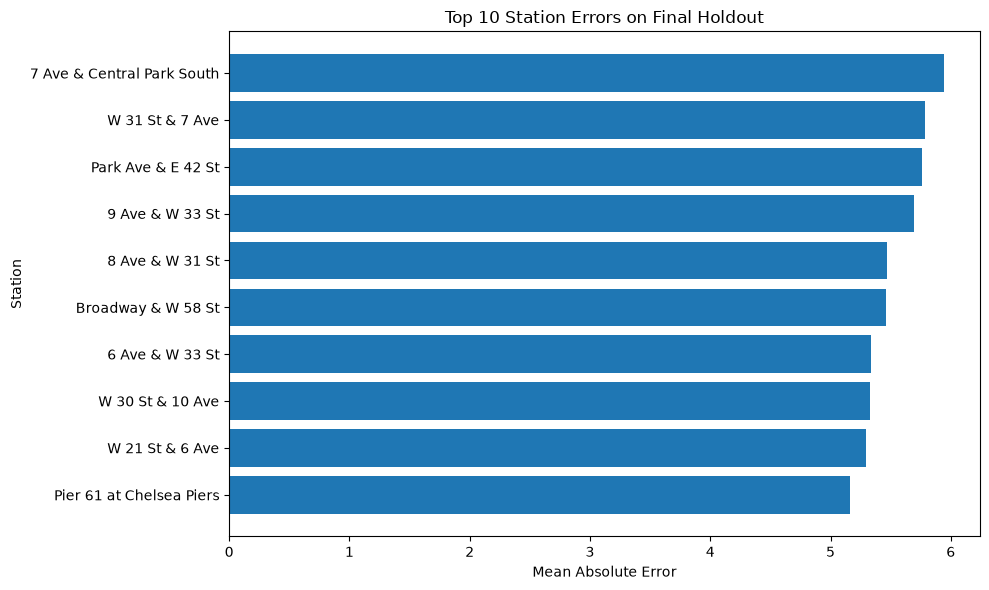

In [10]:
top_station_errors = active_station_errors.sort_values("mae", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_station_errors["station_name"],
    top_station_errors["mae"],
)
plt.gca().invert_yaxis()
plt.xlabel("Mean Absolute Error")
plt.ylabel("Station")
plt.title("Top 10 Station Errors on Final Holdout")
plt.tight_layout()
plt.show()

In [11]:
inactive_stations = station_errors[station_errors["actual_pickups"] == 0]

inactive_stations

,station_id,station_name,actual_pickups,predicted_pickups,mae,rmse,total_error,relative_error_pct
3,5788.13,Lafayette St & E 8 St,0,3.046238,0.018132,0.018589,3.046238,inf


### Inactive Station Check

One selected station had zero pickups during the final holdout. To understand whether this was a temporary final-week issue or a longer station availability issue, we check monthly pickup totals for that station.

In [12]:
inactive_station_ids = inactive_stations["station_id"].tolist()

inactive_station_monthly = (
    features[features["station_id"].isin(inactive_station_ids)]
    .assign(year_month=lambda df: df["timestamp"].dt.to_period("M").astype(str))
    .groupby(["station_id", "station_name", "year_month"])
    .agg(
        total_pickups=("pickups", "sum"),
        active_hours=("pickups", lambda x: (x > 0).sum()),
        total_hours=("pickups", "count"),
    )
    .reset_index()
)

inactive_station_monthly

,station_id,station_name,year_month,total_pickups,active_hours,total_hours
0,5788.13,Lafayette St & E 8 St,2026-01,2780,314,408
1,5788.13,Lafayette St & E 8 St,2026-02,4692,515,672
2,5788.13,Lafayette St & E 8 St,2026-03,9403,650,744
3,5788.13,Lafayette St & E 8 St,2026-04,11281,625,720
4,5788.13,Lafayette St & E 8 St,2026-05,0,0,744


The inactive station was highly active from January through April but had zero pickups throughout May. This suggests that the station was likely unavailable, removed, renamed, or otherwise absent from the trip data during the final test month. Because station availability is different from demand forecasting, a production system should filter out inactive stations before presenting forecasts.

## Largest Individual Forecast Errors

Finally, we inspect the largest station-hour errors to understand whether the biggest misses are isolated spikes, commute-period shifts, weather-related changes, or station-specific anomalies.

In [13]:
largest_misses = (
    predictions
    .sort_values("absolute_error", ascending=False)
    [
        [
            "timestamp",
            "station_id",
            "station_name",
            "pickups",
            "prediction",
            "error",
            "absolute_error",
            "temperature_c",
            "precipitation_mm",
            "is_precipitating",
        ]
    ]
    .head(20)
)

largest_misses.round(2)

C:\Users\Sean\AppData\Local\Temp\ipykernel_48980\3909838038.py:21: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  largest_misses.round(2)


,timestamp,station_id,station_name,pickups,prediction,error,absolute_error,temperature_c,precipitation_mm,is_precipitating
62393,2026-05-28 17:00:00,6492.08,9 Ave & W 33 St,161,103.48,-57.52,57.52,18.5,0.0,0
78786,2026-05-26 18:00:00,6912.01,7 Ave & Central Park South,112,61.92,-50.08,50.08,23.3,0.0,0
78903,2026-05-31 15:00:00,6912.01,7 Ave & Central Park South,88,43.99,-44.01,44.01,23.9,0.0,0
42588,2026-05-25 12:00:00,6233.04,Pier 61 at Chelsea Piers,52,8.59,-43.41,43.41,16.8,0.4,1
52472,2026-05-26 08:00:00,6432.09,Park Ave & E 42 St,71,30.46,-40.54,40.54,17.5,0.0,0
62321,2026-05-25 17:00:00,6492.08,9 Ave & W 33 St,22,61.72,39.72,39.72,20.6,0.0,0
62345,2026-05-26 17:00:00,6492.08,9 Ave & W 33 St,154,114.89,-39.11,39.11,25.0,0.0,0
75569,2026-05-29 17:00:00,6822.09,1 Ave & E 68 St,24,62.74,38.74,38.74,25.5,0.0,0
52457,2026-05-25 17:00:00,6432.09,Park Ave & E 42 St,9,46.74,37.74,37.74,20.6,0.0,0
42595,2026-05-25 19:00:00,6233.04,Pier 61 at Chelsea Piers,29,66.50,37.50,37.50,20.9,0.0,0


### Largest Error Interpretation

The largest individual misses are concentrated during peak daytime and evening periods at high-traffic stations. Most of the largest errors are underpredictions, meaning the model tends to smooth out unusually large station-hour spikes rather than fully matching them.

Several large misses occur around Midtown, Penn Station, Chelsea, and Central Park South. These locations may be influenced by commuter flows, tourism, events, and station-specific availability patterns that are not fully captured by the current feature set.

This suggests that future model improvements should focus less on general daily seasonality and more on station-level redistribution, local events, station availability, and peak-period demand spikes.


In [14]:
largest_misses_summary = (
    largest_misses
    .assign(
        direction=np.where(largest_misses["error"] > 0, "overprediction", "underprediction"),
        date=largest_misses["timestamp"].dt.date,
        hour=largest_misses["timestamp"].dt.hour,
    )
    .groupby("direction")
    .agg(
        count=("absolute_error", "count"),
        mean_absolute_error=("absolute_error", "mean"),
        max_absolute_error=("absolute_error", "max"),
    )
    .reset_index()
)

largest_misses_summary.round(2)

,direction,count,mean_absolute_error,max_absolute_error
0,overprediction,5,38.20,39.72
1,underprediction,15,38.45,57.52


In [15]:
largest_misses_by_hour = (
    largest_misses
    .assign(hour=largest_misses["timestamp"].dt.hour)
    .groupby("hour")
    .size()
    .reset_index(name="count_in_top_20")
    .sort_values("count_in_top_20", ascending=False)
)

largest_misses_by_hour

,hour,count_in_top_20
4,17,8
5,18,3
1,12,2
2,14,2
7,23,2
0,8,1
3,15,1
6,19,1


## Feature Importance

To understand which inputs matter most for the v1 operational model, we use permutation importance on the locked May holdout.

Permutation importance works by randomly shuffling one feature at a time and measuring how much model error gets worse. If shuffling a feature greatly increases MAE, that feature was important to the model.

In [16]:
importance_result = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
)

feature_importance = (
    pd.DataFrame(
        {
            "feature": FEATURE_COLUMNS,
            "mae_increase": importance_result.importances_mean,
            "std": importance_result.importances_std,
        }
    )
    .sort_values("mae_increase", ascending=False)
    .reset_index(drop=True)
)

feature_importance.round(4)

,feature,mae_increase,std
0,lag_24,1.5140,0.0628
1,lag_336,1.2208,0.0413
2,lag_168,1.0636,0.0240
3,relative_humidity_pct,0.9198,0.0527
4,hour,0.5178,0.0330
5,rolling_mean_168,0.4909,0.0233
6,station_id,0.3922,0.0242
7,temperature_c,0.1527,0.0169
8,hour_cos,0.1110,0.0207
9,day_of_week_sin,0.0744,0.0117


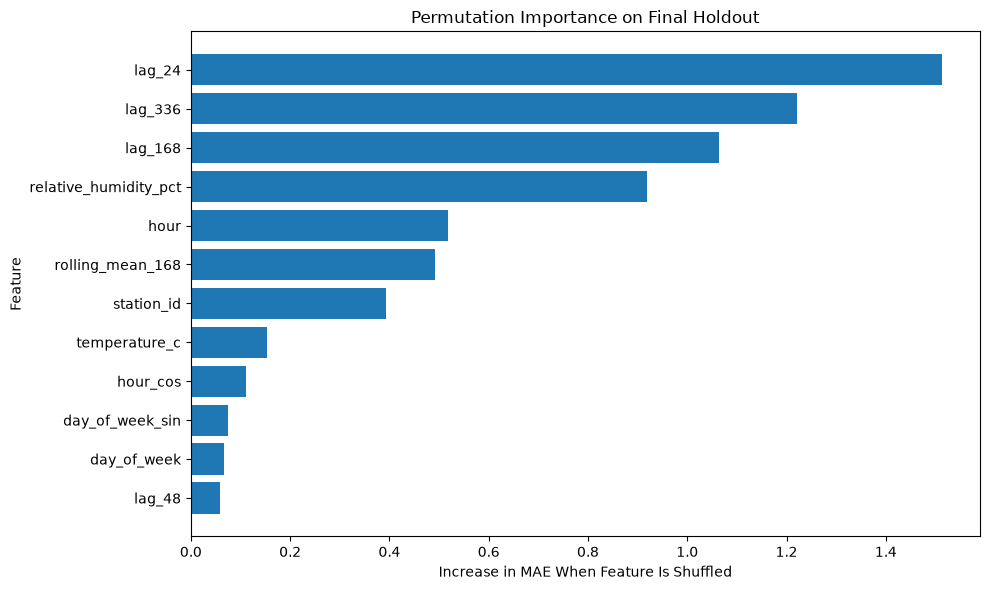

In [17]:
top_features = feature_importance.head(12).sort_values("mae_increase")

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["feature"],
    top_features["mae_increase"],
)
plt.xlabel("Increase in MAE When Feature Is Shuffled")
plt.ylabel("Feature")
plt.title("Permutation Importance on Final Holdout")
plt.tight_layout()
plt.show()

### Feature Importance Interpretation

The operational model relies most heavily on recent and seasonal demand history. The strongest feature is same-hour demand from the previous day, followed by demand from two weeks earlier and one week earlier. This confirms that Citi Bike demand is highly seasonal at daily and weekly time scales.

Weather still contributes useful information. Relative humidity is the strongest weather-related feature on the final holdout, while temperature also has measurable importance. Raw precipitation has lower importance during this particular holdout because most final-test hours were dry. This does not mean precipitation is unimportant overall; rather, it had fewer opportunities to affect predictions during this specific week.

Station identity and rolling average demand also matter, showing that the model learns both location-specific demand levels and recent station behavior.

Some features have zero or negative importance on this holdout. Month is not useful because the final test period is entirely in May, and weekend status is mostly redundant with day of week. Weather code appears slightly noisy or redundant compared with the other weather variables.


## Final Diagnostic Summary

The v1 operational model performs well on the locked May 25–31 holdout, achieving an MAE of 4.85 and RMSE of 7.40 using archived 24-hour-ahead weather forecasts.

The model is strongest at capturing overall daily and hourly demand levels. Its largest errors occur during high-volume peak periods, especially around 5–6 PM, where total demand is often predicted accurately but station-level demand is misallocated.

Station-level errors are highest around Midtown, Penn Station, Chelsea, and Central Park South. These locations likely reflect a mix of commuter traffic, tourism, local events, and station-specific demand spikes.

One selected station, Lafayette St & E 8 St, had zero pickups throughout May despite high activity from January through April. This appears to be a station availability issue rather than a normal forecasting error. Future versions should filter unavailable stations before presenting predictions.

Permutation importance shows that the model relies most heavily on lagged demand features, especially same-hour demand from the previous day, two weeks earlier, and one week earlier. Weather contributes additional predictive value, especially through relative humidity and temperature, while precipitation had limited importance during this mostly dry final holdout week.

Overall, the v1 model is a defensible operational forecasting baseline. The most promising future improvements are longer historical training data, station availability features, holiday/event indicators, and better handling of peak-period station-level demand spikes.
